# Прогнозирование платежей с применением ансамбля 2 моделей на реальных данных

Прогнозируем суммы платежей на агрегированных данных на следующие день/неделю/месяц с учетом отобранных и протестированных методов обработки данных и обучения моделей.

Данные подготовлены для прогнозирования сумм исходя из описательных признаков **без учета** временной составляющей, без добавления нулевых дней в датасет и с применением двух моделей: MLP Catboost и последующим взвешиванием прогнозов.

**UPDATE (Вывод)**:
Данный пааплайн сравнивался с аналогичным из 3-х моделей на базе всех фондов, до user_id 272 по количеству платежей, более мелкие фонды уже не проходили по необходимым минимальным требованиям моделей - сплошные пропуски.  

**Качество моделей в целом**
- **3models** (учёт временной структуры, модели LSTM + SARIMAX + CatBoost)  
  показывают **значительно лучшие метрики**, чем **2models** (MLP + CatBoost без учёта времени), особенно на фондах с большим количеством платежей (`payments_count > 500`).

- **RMSE** (абсолютная ошибка в значениях) у 3models почти всегда **меньше или сравнима** с 2models, особенно на фондах с большим средним чеком.

**Зависимость от количества данных**
- При **маленьком количестве платежей** (`payments_count < 200`) разница между 2models и 3models становится **меньше** или может быть **неустойчивой** из-за высокой дисперсии данных и влияния нулевых дней.

- При **среднем и большом количестве данных** (`payments_count > 500`) преимущество **3models** становится **очевидным** и **стабильным**.

**Промежуточный вывод**
- Для **реальной эксплуатации** (особенно для фондов с более длинной историей и большим числом платежей) **3models** — **предпочтительный пайплайн**.
- 2models можно рассматривать **только для очень коротких рядов** или если нужно быстрое обучение без учёта временной структуры.

---

<a id='К-содержанию'></a>
**Содержание проекта** 
- [Загрузка и предобработка данных](#Загрузка-и-предобработка-данных)
- [Подготовка данных, агрегирование и генерация доппризнаков для прогнозирования сумм платежей](#Подготовка-данных,-агрегирование-и-генерация-доппризнаков-для-прогнозирования-сумм-платежей)
- [MLP](#MLP-подготовка-данных)  
    - [Подготовка данных](#MLP-подготовка-данных)  
    - [Построение и обучение модели](#MLP-построение-и-обучение-модели)  
    - [Валидация модели с визуализацией прогноза](#MLP-валидация-модели-с-визуализацией-прогноза)  
- [Catboost](#Catboost-подготовка-данных)  
    - [Подготовка данных](#Catboost-подготовка-данных)  
    - [Построение и обучение модели](#Catboost-построение-и-обучение-модели)  
    - [Валидация модели с визуализацией прогноза](#Catboost-валидация-модели-с-визуализацией-прогноза)
- [Подбор модели ансамбля прогнозов на валидационной выборке](#Подбор-модели-ансамбля-прогнозов-на-валидационной-выборке)
- [Тестирование ансамбля прогнозов на тестовой выборке](#Тестирование-ансамбля-прогнозов-на-тестовой-выборке)


In [1]:
%%capture
!pip install torch
!pip install spacy
!python -m spacy download ru_core_news_sm

In [2]:
# 📦 стандартные библиотеки Python
import os
import random
import re
import pickle

# 🧮 научные и табличные библиотеки
import numpy as np
import pandas as pd

# 📊 визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# ⏳ прогресс-бары
from tqdm.notebook import tqdm

# 🧠 обработка текста и NLP
import spacy
nlp = spacy.load("ru_core_news_sm")
from transformers import AutoTokenizer, AutoModel

# 🤖 pyTorch
import torch
from torch import nn
import torch.optim as optim

# 🛠 scikit-learn: пайплайны, препроцессинг, модели
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, make_scorer


# 🧠 CatBoost
from catboost import CatBoostRegressor

# 📉 PCA
from sklearn.decomposition import PCA

In [3]:
# вынесем блок с настройками и функциями

# зададим стандарт датафрейма перед загрузкой
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('future.no_silent_downcasting', True)


# устанавливаем фиксированное значение для всех случайных библиотек
RANDOM_STATE = 42

def seed_all(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False
seed_all(RANDOM_STATE)

# функция предобработки текста
def preprocess_text(text):
    # удаляем знаки пунктуации
    text = re.sub(r'[^\w\s]', ' ', text)
    # приводим к нижнему регистру
    text = text.lower()
    # делаем лемматизацию с использованием spaCy
    doc = nlp(text)
    text = " ".join([token.lemma_ for token in doc])
    return text

# задаем функцию для получения усредненного эмбеддинга текста
def get_embedding(text,tokenizer,model):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()


# cоздаём функцию и метрику smape
def smape(y_true, y_pred):
    return 100 * np.mean(np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2))

smape_scorer = make_scorer(smape, greater_is_better=False)

# создаем функцию MASE
def mase(y_true, y_pred, y_train, seasonality=1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_train = np.asarray(y_train)
    scale = np.mean(np.abs(y_train[seasonality:] - y_train[:-seasonality]))
    return np.mean(np.abs(y_true - y_pred)) / scale

<a id='Загрузка-и-предобработка-данных'></a> 
## Загрузка и предобработка данных
[К содержанию](#К-содержанию)

In [4]:
# импортируем данные
pth1 = 'data_3.csv'
pth2 = 'users_actual.csv'

if os.path.exists(pth1) and os.path.exists(pth2):
    data_full = pd.read_csv(pth1)
    users_actual = pd.read_csv(pth2)
else:
    print('Something is wrong')

data_full.info()
display(data_full.head(2))
display(users_actual.head(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411434 entries, 0 to 411433
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  411434 non-null  int64  
 1   account_id                          411434 non-null  int64  
 2   contractor_id                       411434 non-null  int64  
 3   date                                411434 non-null  object 
 4   payments_amount                     411434 non-null  float64
 5   purpose                             410518 non-null  object 
 6   article_id                          411434 non-null  int64  
 7   project_id                          411434 non-null  int64  
 8   counterpartie_id                    411434 non-null  int64  
 9   donor_id                            411434 non-null  int64  
 10  robot_id                            411434 non-null  int64  
 11  donor_cat_id              

,id,account_id,contractor_id,date,payments_amount,purpose,article_id,project_id,counterpartie_id,donor_id,robot_id,donor_cat_id,accounts__id,accounts__user_id,articles__id,articles__user_id,articles__parent_id,projects__id,projects__user_id,projects__parent_id,counterparties__id,counterparties__user_id,counterparties__parent_id,robots__id,robots__user_id,article_alternative_names__user_id
0,6000,28,1210,2022-05-18,17500.00,"Оплата по договору об оказании услуг № 4 от 16.05.2022 за услуги по консультированию, НДС не облагается.",378,75,137,0,-1,135,28.00,41.00,378.00,41.00,376.00,75.00,41.00,17.00,135.00,41.00,133.00,NaN,NaN,41.00
1,6002,28,1210,2022-06-01,17500.00,"Оплата по договору об оказании услуг № 4 от 16.05.2022 за услуги по консультированию, НДС не облагается.",378,75,137,0,-1,135,28.00,41.00,378.00,41.00,376.00,75.00,41.00,17.00,135.00,41.00,133.00,NaN,NaN,41.00


,id
0,47
1,65


In [5]:
# проверяем Nan в user_id
display(data_full['accounts__user_id'].isna().sum())

# заполняем accounts__user_id значениями из других столбцов
data_full['accounts__user_id'] = (
    data_full['accounts__user_id']
    .fillna(data_full['articles__user_id'])
    .fillna(data_full['projects__user_id'])
    .fillna(data_full['counterparties__user_id'])
    .fillna(data_full['robots__user_id'])
    .fillna(data_full['article_alternative_names__user_id'])
)

# проверяем еще раз
display(data_full['accounts__user_id'].isna().sum())

21076

18840

In [6]:
# отфильтруем данные по актуальным пользователям и уберем технические поступления - возврат депозитов, переводы собственных средств
data_actual_id_wodepo = data_full[~data_full['purpose'].str.contains('вклад', na=False) & 
                             ~data_full['purpose'].str.contains('депози', na=False) &
                             ~data_full['purpose'].str.contains('собствен', na=False)&
                             ~data_full['purpose'].str.contains('процент', na=False)&
                             data_full['accounts__user_id'].isin(users_actual['id'])]

data_actual_id_wodepo['id'].count()

249513

In [7]:
# столбцы с дублирующими id, которые использовались при объединении данных при выгрузке из БД, также пустые столбцы и техстолбцы с одним значением
data = data_actual_id_wodepo.drop(['robot_id','accounts__id','articles__id','articles__user_id','projects__id','projects__user_id','counterparties__id',
                                   'counterparties__user_id','robots__user_id','article_alternative_names__user_id'], axis=1)


In [8]:
# поправим типы данных и заполним пропуски метками missing (для текстовых значений категорий) и 0 для пропущенных ID
data[['articles__parent_id','projects__parent_id','counterparties__parent_id','robots__id']] = data[['articles__parent_id','projects__parent_id','counterparties__parent_id','robots__id']].fillna(0).astype('int64')

data['purpose'] = data['purpose'].fillna('missing')

# конвертируем дату в datetime
data['date'] = pd.to_datetime(data['date'])

# переименуем и поправим тип столбца с фондами
data = data.rename(columns={'accounts__user_id': 'user_id'})
data['user_id'] = data['user_id'].fillna(0).astype('int64')

In [9]:
# закодируем текстовое поле
if os.path.exists("2try_data_with_purpose_mean.parquet"):
    data = pd.read_parquet("2try_data_with_purpose_mean.parquet")
else:
    tokenizer = AutoTokenizer.from_pretrained('DeepPavlov/rubert-base-cased')
    model = AutoModel.from_pretrained('DeepPavlov/rubert-base-cased')

    # предобработка текста
    tqdm.pandas(desc="Предобработка текстов")
    data["clean_purpose"] = data["purpose"].progress_apply(preprocess_text)

    # генерация эмбеддингов
    tqdm.pandas(desc="Генерация эмбеддингов")
    data["purpose_emb"] = data["clean_purpose"].progress_apply(lambda x: get_embedding(x, tokenizer, model))

    # 1. усредняем эмбеддинг в одно число
    data["purpose_mean"] = data["purpose_emb"].apply(lambda x: float(np.mean(x)))

    # 2. PCA на 5 главных компонентах
    purpose_vectors = np.vstack(data["purpose_emb"])
    pca = PCA(n_components=5,random_state=RANDOM_STATE)
    purpose_pca_features = pca.fit_transform(purpose_vectors)

    pca_column_names = [f"purpose_pca_{i+1}" for i in range(5)]
    data[pca_column_names] = purpose_pca_features

    # удаляем ненужные столбцы
    data.drop(columns=["purpose", "clean_purpose", "purpose_emb"], inplace=True)

    # сохраняем результат
    data.to_parquet("2try_data_with_purpose_mean.parquet", index=False)

In [10]:
# проверим дубликаты
print('Количество дубликатов: ', data.duplicated().sum().sum())
# проверим пропуски
print('Количество пропусков: ', data.isna().sum().sum())

data = data.drop('id', axis=1)  # удаляем id операции перед агрегированием

Количество дубликатов:  0
Количество пропусков:  0


In [11]:
data.head()

,account_id,contractor_id,date,payments_amount,article_id,project_id,counterpartie_id,donor_id,donor_cat_id,user_id,articles__parent_id,projects__parent_id,counterparties__parent_id,robots__id,purpose_mean,purpose_pca_1,purpose_pca_2,purpose_pca_3,purpose_pca_4,purpose_pca_5
0,60,76,2023-01-16,5637.60,3476,3286,0,0,555,65,2176,2896,553,0,-0.00,3.15,-4.20,2.27,1.62,2.09
1,60,76,2023-01-20,3888.00,3476,3286,0,0,555,65,2176,2896,553,0,-0.00,3.16,-4.14,2.33,1.64,2.11
2,60,76,2023-01-24,1069.20,3476,3286,0,0,555,65,2176,2896,553,0,-0.00,3.17,-4.24,2.13,1.67,2.15
3,60,76,2023-01-25,3888.00,3476,3286,0,0,555,65,2176,2896,553,0,-0.00,3.34,-4.12,2.23,1.67,2.09
4,60,76,2023-01-30,972.00,3476,3286,0,0,555,65,2176,2896,553,0,-0.00,3.15,-3.96,2.17,1.78,2.06


In [12]:
# закодируем данные с поомщью frequency_encoding по каждому user_id
id_cols = [
    'account_id', 'contractor_id', 'article_id', 'project_id',
    'counterpartie_id', 'donor_id', 'donor_cat_id',
    'articles__parent_id', 'projects__parent_id',
    'counterparties__parent_id', 'robots__id'
]

data_fe = data.copy()

# создаем временный столбец с общим количеством записей для каждого пользователя
data_fe['user_total_counts_col'] = data_fe.groupby('user_id')['user_id'].transform('size')

# кодируем каждый из столбцов id_cols
for col in id_cols:
    
    encoded_col_name = f'{col}_ufreq' #задаем имя столбцу
    # считаем количество вхождений категории 'col' для данного 'user_id'
    numerator = data_fe.groupby(['user_id', col])[col].transform('size')
    # считаем долю и записываем в столбец
    data_fe[encoded_col_name] = numerator.astype(float) / data_fe['user_total_counts_col'].astype(float)

# удаляем временный столбец с общим количеством
data_fe.drop(columns=['user_total_counts_col'], inplace=True)


In [13]:
# агрегация платежей по дням и пользователям

# делаем список колонок для расчета nunique
nunique_cols = [
    'account_id', 'contractor_id', 'article_id', 'project_id',
    'counterpartie_id', 'donor_id', 'donor_cat_id',
    'articles__parent_id', 'projects__parent_id',
    'counterparties__parent_id', 'robots__id'
]

# делаем список колонок с кодированными значениями текстового поля
purpose_mean_cols = [
    'purpose_mean', 'purpose_pca_1', 'purpose_pca_2',
    'purpose_pca_3', 'purpose_pca_4', 'purpose_pca_5'
]

# делаем список кодированных категориальных колонок
col_ufreq = [col for col in data_fe.columns if col.endswith('_ufreq')]

# агрегируем данные до уровня дня
data_daily_agg = data_fe.groupby(['user_id', 'date']).agg(
    **{f'day_{col}_nunique': (col, 'nunique') for col in nunique_cols},
    
    day_payments_sum=('payments_amount', 'sum'),
    day_payments_count=('payments_amount', 'count'),
    day_min_payment=('payments_amount', 'min'),
    day_max_payment=('payments_amount', 'max'),
    
    **{f'day_{col}': (col, 'mean') for col in purpose_mean_cols},
    
    **{f'{col}_mean': (col, 'mean') for col in col_ufreq},
    **{f'{col}_std': (col, 'std') for col in col_ufreq},
                                                          
    ).reset_index()

# заполним NaN в std колонках нулями (там где было одно наблюдение/платеж)
std_cols = [col for col in data_daily_agg.columns if col.endswith('_std')]
data_daily_agg[std_cols] = data_daily_agg[std_cols].fillna(0)

In [14]:
# заполним пропущенные дни нулевыми значениями, чтобы сохранить структуру временного ряда

# создадим функцию
def fill_missing_dates(group):
    full_range = pd.date_range(group['date'].min(), group['date'].max(), freq='D')
    group = group.set_index('date').reindex(full_range)
    group['user_id'] = group['user_id'].iloc[0]
    return group.reset_index().rename(columns={'index': 'date'})

# применим эту функцию к каждой группе после группировки по user_id
data_daily_agg_filled = data_daily_agg.groupby('user_id', group_keys=False).apply(fill_missing_dates)

# заполним пропущенные значения нулями
data_daily_agg_filled = data_daily_agg_filled.fillna(0)


/var/folders/yf/tnhxwgts2035718d0nhj30rw0000gn/T/ipykernel_45255/3219682915.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_daily_agg_filled = data_daily_agg.groupby('user_id', group_keys=False).apply(fill_missing_dates)


In [15]:
# добавляем столбцы с днем недели и номером недели в месяце + кодируем их с помощью циклического кодирования (sin/cos)

# день недели (0 — понедельник, 6 — воскресенье)
data_daily_agg_filled['day_of_week'] = data_daily_agg_filled['date'].dt.weekday
data_daily_agg_filled['day_of_week_sin'] = np.sin(2 * np.pi * data_daily_agg_filled['day_of_week'] / 7)
data_daily_agg_filled['day_of_week_cos'] = np.cos(2 * np.pi * data_daily_agg_filled['day_of_week'] / 7)

# номер недели в месяце (1–5, 6 неделя скорее добавит шума,и вряд ли выучится хорошо)
data_daily_agg_filled['week_number'] = data_daily_agg_filled['date'].dt.day.sub(1).floordiv(7).add(1)
data_daily_agg_filled['week_number_sin'] = np.sin(2 * np.pi * data_daily_agg_filled['week_number'] / 5)
data_daily_agg_filled['week_number_cos'] = np.cos(2 * np.pi * data_daily_agg_filled['week_number'] / 5)

In [16]:
# добавим по платежам скользящее среднее  и лаги за последние n дней (например, 7 дней), исключая текущий день
ROLLING_WINDOW = 7
LAGS = 8

def rolling_mean(group, rolling_window, lags):
    group = group.sort_values('date')
    group['rolling_day_payments'] = (group['day_payments_sum'].shift(1)
                                                 .rolling(window=rolling_window, min_periods=1)
                                                 .mean())
    for lag in range(1, lags):
        group[f'day_payments_sum_lag_{lag}'] = group['day_payments_sum'].shift(lag)
    
    return group

# применим эту функцию к каждой группе после группировки по user_id
data_daily_agg_filled_added = (
    data_daily_agg_filled
    .groupby('user_id', group_keys=False)
    .apply(lambda group: rolling_mean(group, rolling_window=ROLLING_WINDOW, lags=LAGS)))

data_daily_agg_filled_added = data_daily_agg_filled_added.fillna(0)
data_daily_agg_filled_added.to_csv('2try_data_daily_agg_filled_added.csv')
data_daily_agg_filled_added.head()


/var/folders/yf/tnhxwgts2035718d0nhj30rw0000gn/T/ipykernel_45255/438147222.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: rolling_mean(group, rolling_window=ROLLING_WINDOW, lags=LAGS)))


,date,user_id,day_account_id_nunique,day_contractor_id_nunique,day_article_id_nunique,day_project_id_nunique,day_counterpartie_id_nunique,day_donor_id_nunique,day_donor_cat_id_nunique,day_articles__parent_id_nunique,day_projects__parent_id_nunique,day_counterparties__parent_id_nunique,day_robots__id_nunique,day_payments_sum,day_payments_count,day_min_payment,day_max_payment,day_purpose_mean,day_purpose_pca_1,day_purpose_pca_2,day_purpose_pca_3,day_purpose_pca_4,day_purpose_pca_5,account_id_ufreq_mean,contractor_id_ufreq_mean,article_id_ufreq_mean,project_id_ufreq_mean,counterpartie_id_ufreq_mean,donor_id_ufreq_mean,donor_cat_id_ufreq_mean,articles__parent_id_ufreq_mean,projects__parent_id_ufreq_mean,counterparties__parent_id_ufreq_mean,robots__id_ufreq_mean,account_id_ufreq_std,contractor_id_ufreq_std,article_id_ufreq_std,project_id_ufreq_std,counterpartie_id_ufreq_std,donor_id_ufreq_std,donor_cat_id_ufreq_std,articles__parent_id_ufreq_std,projects__parent_id_ufreq_std,counterparties__parent_id_ufreq_std,robots__id_ufreq_std,day_of_week,day_of_week_sin,day_of_week_cos,week_number,week_number_sin,week_number_cos,rolling_day_payments,day_payments_sum_lag_1,day_payments_sum_lag_2,day_payments_sum_lag_3,day_payments_sum_lag_4,day_payments_sum_lag_5,day_payments_sum_lag_6,day_payments_sum_lag_7
0,2021-12-31,47.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,14024.45,2.00,2606.47,11417.98,-0.00,-4.86,-3.47,-2.08,1.52,0.66,0.50,0.00,0.00,0.00,0.08,0.24,0.79,0.00,0.00,0.79,0.05,0.27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4,-0.43,-0.90,5,-0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2022-01-01,47.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5,-0.97,-0.22,1,0.95,0.31,14024.45,14024.45,0.00,0.00,0.00,0.00,0.00,0.00
2,2022-01-02,47.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,100.00,1.00,100.00,100.00,0.00,-1.26,-1.76,-2.18,2.72,1.30,0.69,0.02,0.39,0.65,0.09,0.02,0.79,0.70,0.65,0.79,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6,-0.78,0.62,1,0.95,0.31,7012.22,0.00,14024.45,0.00,0.00,0.00,0.00,0.00
3,2022-01-03,47.00,2.00,3.00,3.00,2.00,2.00,4.00,1.00,2.00,2.00,1.00,4.00,7166.50,4.00,10.00,6246.50,-0.00,2.77,-0.96,0.65,0.16,-0.31,0.59,0.27,0.33,0.56,0.42,0.14,0.79,0.60,0.57,0.79,0.12,0.19,0.31,0.07,0.17,0.09,0.16,0.00,0.20,0.15,0.00,0.14,0,0.00,1.00,1,0.95,0.31,4708.15,100.00,0.00,14024.45,0.00,0.00,0.00,0.00
4,2022-01-04,47.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,0.78,0.62,1,0.95,0.31,5322.74,7166.50,100.00,0.00,14024.45,0.00,0.00,0.00


In [17]:
# отбираем только исходные дни с имеющимися данными
data_final = data_daily_agg_filled_added.merge(
    data_daily_agg[['user_id', 'date']],
    on=['user_id', 'date'],
    how='inner'
)

# преобразуем дату в индекс
data_final = data_final.set_index('date', drop=True)
data_final.index.name = None

In [18]:
data_final.head()

,user_id,day_account_id_nunique,day_contractor_id_nunique,day_article_id_nunique,day_project_id_nunique,day_counterpartie_id_nunique,day_donor_id_nunique,day_donor_cat_id_nunique,day_articles__parent_id_nunique,day_projects__parent_id_nunique,day_counterparties__parent_id_nunique,day_robots__id_nunique,day_payments_sum,day_payments_count,day_min_payment,day_max_payment,day_purpose_mean,day_purpose_pca_1,day_purpose_pca_2,day_purpose_pca_3,day_purpose_pca_4,day_purpose_pca_5,account_id_ufreq_mean,contractor_id_ufreq_mean,article_id_ufreq_mean,project_id_ufreq_mean,counterpartie_id_ufreq_mean,donor_id_ufreq_mean,donor_cat_id_ufreq_mean,articles__parent_id_ufreq_mean,projects__parent_id_ufreq_mean,counterparties__parent_id_ufreq_mean,robots__id_ufreq_mean,account_id_ufreq_std,contractor_id_ufreq_std,article_id_ufreq_std,project_id_ufreq_std,counterpartie_id_ufreq_std,donor_id_ufreq_std,donor_cat_id_ufreq_std,articles__parent_id_ufreq_std,projects__parent_id_ufreq_std,counterparties__parent_id_ufreq_std,robots__id_ufreq_std,day_of_week,day_of_week_sin,day_of_week_cos,week_number,week_number_sin,week_number_cos,rolling_day_payments,day_payments_sum_lag_1,day_payments_sum_lag_2,day_payments_sum_lag_3,day_payments_sum_lag_4,day_payments_sum_lag_5,day_payments_sum_lag_6,day_payments_sum_lag_7
2021-12-31,47.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,14024.45,2.00,2606.47,11417.98,-0.00,-4.86,-3.47,-2.08,1.52,0.66,0.50,0.00,0.00,0.00,0.08,0.24,0.79,0.00,0.00,0.79,0.05,0.27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4,-0.43,-0.90,5,-0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2022-01-02,47.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,100.00,1.00,100.00,100.00,0.00,-1.26,-1.76,-2.18,2.72,1.30,0.69,0.02,0.39,0.65,0.09,0.02,0.79,0.70,0.65,0.79,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6,-0.78,0.62,1,0.95,0.31,7012.22,0.00,14024.45,0.00,0.00,0.00,0.00,0.00
2022-01-03,47.00,2.00,3.00,3.00,2.00,2.00,4.00,1.00,2.00,2.00,1.00,4.00,7166.50,4.00,10.00,6246.50,-0.00,2.77,-0.96,0.65,0.16,-0.31,0.59,0.27,0.33,0.56,0.42,0.14,0.79,0.60,0.57,0.79,0.12,0.19,0.31,0.07,0.17,0.09,0.16,0.00,0.20,0.15,0.00,0.14,0,0.00,1.00,1,0.95,0.31,4708.15,100.00,0.00,14024.45,0.00,0.00,0.00,0.00
2022-01-06,47.00,2.00,1.00,2.00,2.00,2.00,2.00,1.00,2.00,2.00,1.00,2.00,3616.10,3.00,6.10,3110.00,-0.00,2.83,-2.76,2.16,-0.56,-1.59,0.43,0.53,0.28,0.41,0.34,0.28,0.79,0.43,0.45,0.79,0.24,0.22,0.00,0.03,0.20,0.11,0.03,0.00,0.23,0.17,0.00,0.00,3,0.43,-0.90,1,0.95,0.31,3548.49,0.00,0.00,7166.50,100.00,0.00,14024.45,0.00
2022-01-10,47.00,2.00,3.00,3.00,2.00,3.00,3.00,1.00,2.00,2.00,1.00,5.00,34627.00,11.00,96.10,22000.00,0.00,2.40,-1.91,2.27,0.01,-0.09,0.48,0.29,0.28,0.46,0.27,0.26,0.79,0.48,0.49,0.79,0.13,0.20,0.27,0.04,0.18,0.21,0.08,0.00,0.21,0.15,0.00,0.11,0,0.00,1.00,2,0.59,-0.81,1540.37,0.00,0.00,0.00,3616.10,0.00,0.00,7166.50


## Запускаем обучение моделей

In [20]:
# для выбора фонда посмотрим количество записей оригинального датасета
data['user_id'].value_counts()

user_id
804    96616
812    36681
114    33490
195    13466
722     7994
185     7159
890     6098
237     5792
888     4621
827     4365
279     3961
172     3483
98      3353
838     3067
822     3032
749     2932
782     1679
709     1404
47      1358
123     1250
724     1203
792     1097
777      687
197      622
816      619
714      490
877      412
168      410
712      386
256      368
272      357
876      311
65       292
795      185
732      112
176      107
886       39
284        9
874        4
157        2
Name: count, dtype: int64

In [21]:
# выберем фонд
FUND_ID = 804

data_fund = data_final[data_final['user_id']==FUND_ID].copy() #185

# проверяем монотонность и сортируем при необходимости
if not data_fund.index.is_monotonic_increasing:
    data_fund = data_fund.sort_index()

full_range = pd.date_range(start=data_fund.index.min(), end=data_fund.index.max(), freq='D')
missing_dates = full_range.difference(data_fund.index)
print('Диапазон дат:', data_fund.index.min(), data_fund.index.max())
print(f"Пропущено дат: {len(missing_dates)}")


Диапазон дат: 2024-01-03 00:00:00 2025-01-27 00:00:00
Пропущено дат: 122


In [22]:
# проверим наличие нулевых дней
display(data_fund[data_fund['day_payments_sum']==0]['user_id'].count())

0

In [23]:
data_fund.drop(['user_id'], axis=1, inplace=True)

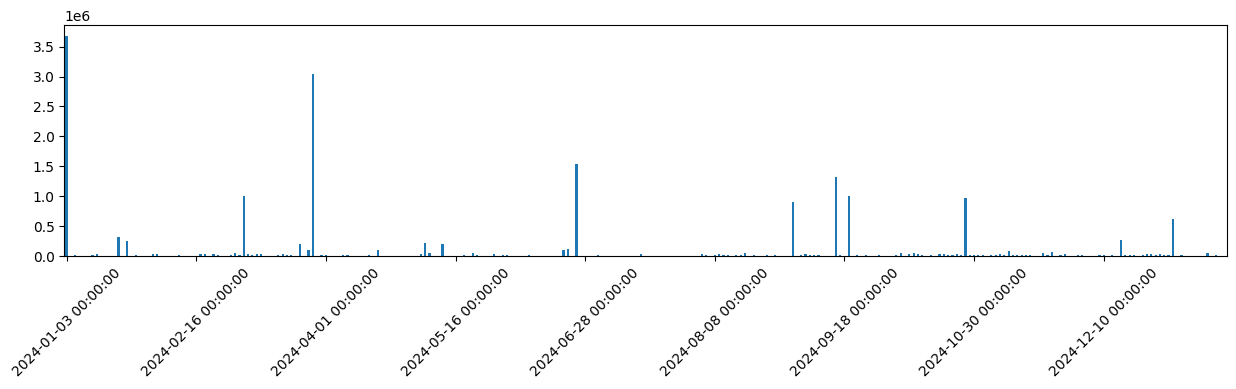

In [24]:
# посмотрим распределение сумм по дням
ax = data_fund['day_payments_sum'].plot(kind='bar',figsize=(15, 3))
ax.set_xticks(ax.get_xticks()[::30])  #настраиваем подписи на оси x
plt.xticks(rotation=45)
plt.show();

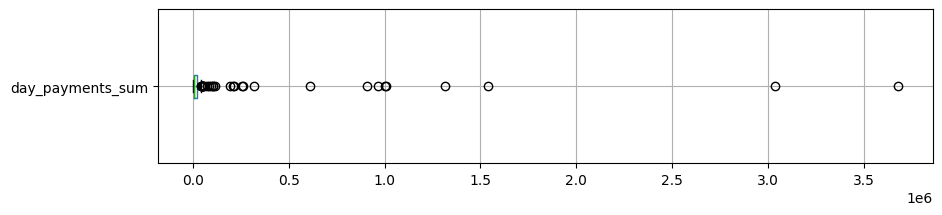

In [25]:
# и в виде boxplot
data_fund[['day_payments_sum']].boxplot(figsize=(10, 2), vert=False);

Далее заменим выбросы более 90%-перцентиля на медианное значение за весь период, и при обучении проверим метрики с заменой выбросов и без.

In [26]:
# заменяем агрегированные дневные суммы из THRESHOLD_CONST перцентиля на медианное значение
TRESHOLD_CONST = 0.90

threshold = data_fund['day_payments_sum'].quantile(TRESHOLD_CONST)
print(threshold)
median_full_sum = data_fund['day_payments_sum'].median()
print(median_full_sum)
data_fund.loc[data_fund['day_payments_sum'] > threshold, 'day_payments_sum'] = median_full_sum

43662.790000000015
7330.78


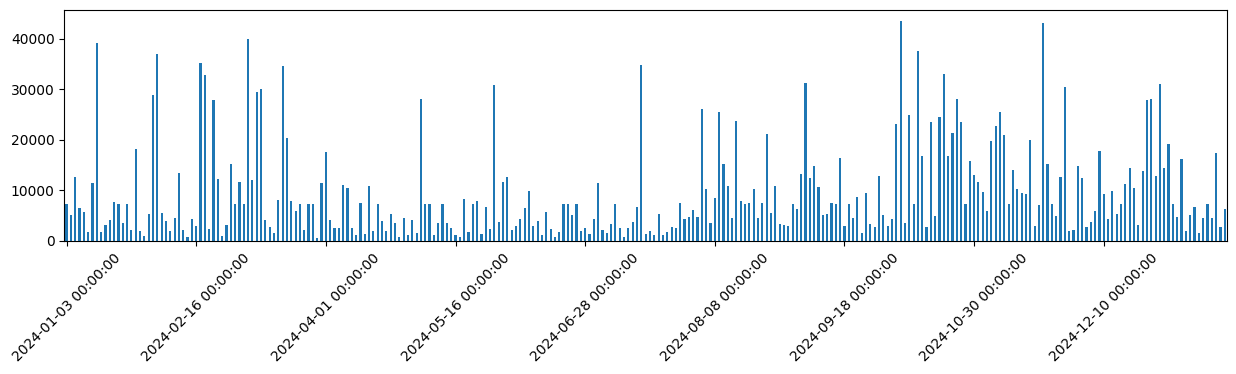

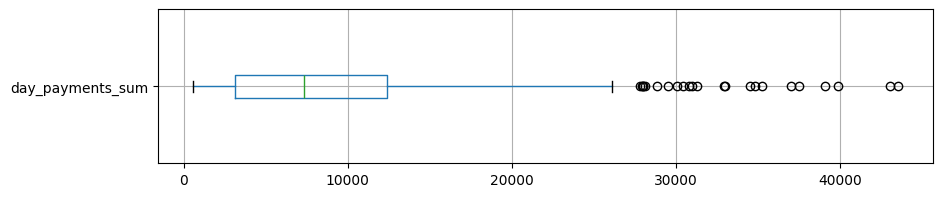

In [27]:
# посмотрим распределение сумм по дням
ax = data_fund['day_payments_sum'].plot(kind='bar',figsize=(15, 3))
ax.set_xticks(ax.get_xticks()[::30])  #настраиваем подписи на оси x
plt.xticks(rotation=45)
plt.show();

# и в виде boxplot
data_fund[['day_payments_sum']].boxplot(figsize=(10, 2), vert=False);

In [28]:
data_fund.isna().sum().sum()

0

In [29]:
# сдвигаем целевую переменную на 1 назад, чтобы модель училась предсказывать по текущему значению признаков будущий день
data_fund_shifted = data_fund.copy()
data_fund_shifted['target_shifted'] = data_fund_shifted['day_payments_sum'].shift(-1)

# убираем последнюю строку, так как она становится NaN из-за сдвига
data_fund_shifted = data_fund_shifted[:-1]

In [30]:
# определяем последние два месяца в данных для валидации и тестирования
test_month = data_fund_shifted.index.max().strftime('%Y-%m')  # последний год-месяц
val_month = (data_fund_shifted.index.max() - pd.DateOffset(months=1)).strftime('%Y-%m')  # предпоследний год-месяц

# разделяем данные
train_data_fund = data_fund_shifted.loc[data_fund_shifted.index < val_month]
val_data_fund = data_fund_shifted.loc[data_fund_shifted.index.strftime('%Y-%m') == val_month]
test_data_fund = data_fund_shifted.loc[data_fund_shifted.index.strftime('%Y-%m') == test_month]

# проверяем размеры и даты
display(train_data_fund.shape, val_data_fund.shape, test_data_fund.shape)

print("Последняя тренировочная дата:", train_data_fund.index.max().date())
print("Первая валидационная дата:", val_data_fund.index.min().date())
print("Последняя валидационная дата:", val_data_fund.index.max().date())
print("Первая тестовая дата:", test_data_fund.index.min().date())

(234, 58)

(22, 58)

(12, 58)

Последняя тренировочная дата: 2024-11-30
Первая валидационная дата: 2024-12-02
Последняя валидационная дата: 2024-12-31
Первая тестовая дата: 2025-01-09


In [31]:
# выделяем категоральные признаки
cat_features = ['day_of_week', 'week_number']

# формируем X_train и y_train
X_train = train_data_fund.drop(['day_payments_sum','target_shifted'], axis=1)
y_train = train_data_fund['target_shifted']

# формируем X_val и y_val
X_val = val_data_fund.drop(['day_payments_sum','target_shifted'], axis=1)
y_val = val_data_fund['target_shifted']

# формируем X_test и y_test
X_test = test_data_fund.drop(['day_payments_sum','target_shifted'], axis=1) 
y_test = test_data_fund['target_shifted']

In [32]:
X_train.head()

,day_account_id_nunique,day_contractor_id_nunique,day_article_id_nunique,day_project_id_nunique,day_counterpartie_id_nunique,day_donor_id_nunique,day_donor_cat_id_nunique,day_articles__parent_id_nunique,day_projects__parent_id_nunique,day_counterparties__parent_id_nunique,day_robots__id_nunique,day_payments_count,day_min_payment,day_max_payment,day_purpose_mean,day_purpose_pca_1,day_purpose_pca_2,day_purpose_pca_3,day_purpose_pca_4,day_purpose_pca_5,account_id_ufreq_mean,contractor_id_ufreq_mean,article_id_ufreq_mean,project_id_ufreq_mean,counterpartie_id_ufreq_mean,donor_id_ufreq_mean,donor_cat_id_ufreq_mean,articles__parent_id_ufreq_mean,projects__parent_id_ufreq_mean,counterparties__parent_id_ufreq_mean,robots__id_ufreq_mean,account_id_ufreq_std,contractor_id_ufreq_std,article_id_ufreq_std,project_id_ufreq_std,counterpartie_id_ufreq_std,donor_id_ufreq_std,donor_cat_id_ufreq_std,articles__parent_id_ufreq_std,projects__parent_id_ufreq_std,counterparties__parent_id_ufreq_std,robots__id_ufreq_std,day_of_week,day_of_week_sin,day_of_week_cos,week_number,week_number_sin,week_number_cos,rolling_day_payments,day_payments_sum_lag_1,day_payments_sum_lag_2,day_payments_sum_lag_3,day_payments_sum_lag_4,day_payments_sum_lag_5,day_payments_sum_lag_6,day_payments_sum_lag_7
2024-01-03,1.00,9.00,3.00,2.00,1.00,1.00,2.00,2.00,1.00,2.00,3.00,137.00,0.01,3671794.35,0.00,2.63,1.97,-0.53,0.04,0.06,1.00,0.91,0.92,0.96,1.00,1.00,0.96,0.96,1.00,0.99,0.92,0.00,0.23,0.16,0.08,0.00,0.00,0.08,0.08,0.00,0.09,0.16,2,0.97,-0.22,1,0.95,0.31,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2024-01-05,1.00,12.00,3.00,2.00,1.00,1.00,2.00,2.00,1.00,1.00,3.00,283.00,0.01,2000.00,0.00,2.78,2.14,-0.56,0.04,0.05,1.00,0.93,0.94,0.96,1.00,1.00,0.96,0.96,1.00,1.00,0.94,0.00,0.19,0.10,0.08,0.00,0.00,0.08,0.08,0.00,0.00,0.10,4,-0.43,-0.90,1,0.95,0.31,1838965.56,0.00,3677931.12,0.00,0.00,0.00,0.00,0.00
2024-01-09,1.00,22.00,4.00,2.00,1.00,1.00,3.00,2.00,1.00,2.00,4.00,664.00,0.01,2920.00,0.00,2.92,2.18,-0.55,0.01,0.07,1.00,0.93,0.94,0.96,1.00,1.00,0.96,0.96,1.00,1.00,0.94,0.00,0.17,0.09,0.05,0.00,0.00,0.06,0.05,0.00,0.04,0.09,1,0.78,0.62,2,0.59,-0.81,613836.08,0.00,0.00,0.00,5085.37,0.00,3677931.12,0.00
2024-01-10,1.00,3.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.00,383.00,0.01,5144.02,0.00,2.91,2.20,-0.56,0.00,0.05,1.00,0.96,0.95,0.96,1.00,1.00,0.96,0.96,1.00,1.00,0.95,0.00,0.07,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05,2,0.97,-0.22,2,0.59,-0.81,527952.42,12650.44,0.00,0.00,0.00,5085.37,0.00,3677931.12
2024-01-11,1.00,10.00,2.00,1.00,1.00,1.00,2.00,1.00,1.00,2.00,2.00,349.00,0.01,3000.00,0.00,2.82,2.20,-0.56,0.02,0.05,1.00,0.94,0.95,0.96,1.00,1.00,0.96,0.96,1.00,1.00,0.95,0.00,0.15,0.05,0.00,0.00,0.00,0.05,0.00,0.00,0.05,0.05,3,0.43,-0.90,2,0.59,-0.81,3459.38,6479.87,12650.44,0.00,0.00,0.00,5085.37,0.00


## MLP
### Подготовка данных
<a id='MLP-подготовка-данных'></a> 
[К содержанию](#К-содержанию)

In [33]:
# масштабируем числовые признаки
scaler_x = StandardScaler()
X_train_num_scaled = scaler_x.fit_transform(X_train.drop(columns=cat_features))
X_val_num_scaled = scaler_x.transform(X_val.drop(columns=cat_features))
X_test_num_scaled = scaler_x.transform(X_test.drop(columns=cat_features))

# кодируем категориальные признаки
X_train_cat_encoded = pd.get_dummies(X_train[cat_features], dtype=float)
X_val_cat_encoded = pd.get_dummies(X_val[cat_features], dtype=float)
X_test_cat_encoded = pd.get_dummies(X_test[cat_features], dtype=float)

# Выравниваем столбцы (если в тестовой или валидационной выборке пропущены категории)
X_train_cat_encoded, X_val_cat_encoded = X_train_cat_encoded.align(X_val_cat_encoded, join='left', axis=1, fill_value=0)
X_train_cat_encoded, X_test_cat_encoded = X_train_cat_encoded.align(X_test_cat_encoded, join='left', axis=1, fill_value=0)
X_val_cat_encoded, X_test_cat_encoded = X_val_cat_encoded.align(X_test_cat_encoded, join='left', axis=1, fill_value=0)

# объединяем обратно
X_train_prepared = np.hstack([X_train_num_scaled, X_train_cat_encoded])
X_val_prepared = np.hstack([X_val_num_scaled, X_val_cat_encoded])
X_test_prepared = np.hstack([X_test_num_scaled, X_test_cat_encoded])

# масштабируем целевую переменную
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# преобразуем обратно в DataFrame для сохранения временных индексов
X_train_prepared = pd.DataFrame(
    X_train_prepared, 
    columns=list(X_train.drop(columns=cat_features).columns) + list(X_train_cat_encoded.columns),
    index=X_train.index)

X_val_prepared = pd.DataFrame(
    X_val_prepared,
    columns=list(X_val.drop(columns=cat_features).columns) + list(X_val_cat_encoded.columns),
    index=X_val.index)

X_test_prepared = pd.DataFrame(
    X_test_prepared, 
    columns=list(X_test.drop(columns=cat_features).columns) + list(X_test_cat_encoded.columns),
    index=X_test.index)

# преобразуем в Series(см.выше)
y_train_scaled = pd.Series(y_train_scaled.ravel(), name=y_train.name, index=y_train.index)
y_val_scaled = pd.Series(y_val_scaled.ravel(), name=y_val.name, index=y_val.index)
y_test_scaled = pd.Series(y_test_scaled.ravel(), name=y_test.name, index=y_test.index)

<a id='LSTM-построение-и-обучение-модели'></a> 
### Построение и обучение модели
[К содержанию](#К-содержанию)

In [34]:
# параметры
n_splits = 7
kf = KFold(n_splits=n_splits, shuffle=False)

rmse_scores_train = []
rmse_scores_test = []
smape_scores_train = []
smape_scores_test = []

# модель MLP
class MLPModel(nn.Module):
    def __init__(self, input_size):
        super(MLPModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            #nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),
            #nn.Dropout(0.1),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)
# преобразуем данные
X_np = X_train_prepared.to_numpy().astype(np.float32)
y_np = y_train_scaled.values.astype(np.float32).reshape(-1, 1)

for train_idx, test_idx in kf.split(X_np):
    X_train_s, X_test_s = X_np[train_idx], X_np[test_idx]
    y_train_s, y_test_s = y_np[train_idx], y_np[test_idx]

    # тензоры
    X_train_tensor = torch.tensor(X_train_s)
    y_train_tensor = torch.tensor(y_train_s)
    X_test_tensor = torch.tensor(X_test_s)
    y_test_tensor = torch.tensor(y_test_s)

    # модель
    input_size = X_np.shape[1]
    model_mlp = MLPModel(input_size)

    criterion = nn.HuberLoss(delta=1.5)
    optimizer = optim.AdamW(model_mlp.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

    # обучение
    num_epochs = 200
    for epoch in range(num_epochs):
        model_mlp.train()
        optimizer.zero_grad()
        output = model_mlp(X_train_tensor)
        loss = criterion(output, y_train_tensor)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            y_train_pred_original = scaler_y.inverse_transform(output.detach().numpy())
            y_train_original = scaler_y.inverse_transform(y_train_tensor.numpy())
            train_rmse = np.sqrt(mean_squared_error(y_train_original, y_train_pred_original))
            train_smape = smape(y_train_original, y_train_pred_original)

    scheduler.step(loss)

    # предсказания
    model_mlp.eval()
    with torch.no_grad():
        y_pred = model_mlp(X_test_tensor)
        y_pred_original = scaler_y.inverse_transform(y_pred.numpy())
        y_test_original = scaler_y.inverse_transform(y_test_tensor.numpy())

        test_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
        test_smape = smape(y_test_original, y_pred_original)

    rmse_scores_train.append(train_rmse)
    rmse_scores_test.append(test_rmse)
    smape_scores_train.append(train_smape)
    smape_scores_test.append(test_smape)

# вывод метрик
print(f"Средний RMSE на тренировочных данных: {np.mean(rmse_scores_train):.4f}, Средний SMAPE на тренировочных данных: {np.mean(smape_scores_train):.4f}")
print(f"Средний RMSE на тестовых данных: {np.mean(rmse_scores_test):.4f}, Средний SMAPE на тестовых данных: {np.mean(smape_scores_test):.4f}")

Средний RMSE на тренировочных данных: 743.7987, Средний SMAPE на тренировочных данных: 8.8147
Средний RMSE на тестовых данных: 15147.3780, Средний SMAPE на тестовых данных: 96.8036


<a id='LSTM-валидация-модели-с-визуализацией-прогноза'></a> 
### Валидация модели с визуализацией прогноза
[К содержанию](#К-содержанию)

In [35]:
y_train_scaled.head()

2024-01-03   -0.47
2024-01-05    0.33
2024-01-09   -0.33
2024-01-10   -0.40
2024-01-11   -0.83
Name: target_shifted, dtype: float64

In [36]:
# преобразуем в тензоры
X_tensor = torch.tensor(X_train_prepared.values, dtype=torch.float32)
y_tensor = torch.tensor(y_train_scaled.values, dtype=torch.float32).view(-1, 1)

# обучение, параметры модели заданы на этапе кросс-валидации, оставляем их же
for epoch in range(num_epochs):
    model_mlp.train()
    optimizer.zero_grad()
    
    output = model_mlp(X_tensor)
    loss = criterion(output, y_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        y_true_orig = scaler_y.inverse_transform(y_tensor.detach().numpy())
        y_pred_orig = scaler_y.inverse_transform(output.detach().numpy())
        rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
        smape_score = smape(y_true_orig, y_pred_orig)
        print(f"Эпоха [{epoch + 1}/{num_epochs}], Потеря: {loss.item():.4f}, RMSE: {rmse:.4f}, SMAPE: {smape_score:.4f}")

Эпоха [10/200], Потеря: 0.0741, RMSE: 3742.1860, SMAPE: 34.9500
Эпоха [20/200], Потеря: 0.0429, RMSE: 2788.9816, SMAPE: 31.7388
Эпоха [30/200], Потеря: 0.0252, RMSE: 2124.9727, SMAPE: 24.8955
Эпоха [40/200], Потеря: 0.0169, RMSE: 1739.8157, SMAPE: 21.1693
Эпоха [50/200], Потеря: 0.0130, RMSE: 1527.1991, SMAPE: 19.2494
Эпоха [60/200], Потеря: 0.0111, RMSE: 1413.7933, SMAPE: 17.3269
Эпоха [70/200], Потеря: 0.0086, RMSE: 1239.5245, SMAPE: 14.3480
Эпоха [80/200], Потеря: 0.0072, RMSE: 1139.7229, SMAPE: 10.8631
Эпоха [90/200], Потеря: 0.0063, RMSE: 1063.6477, SMAPE: 8.6591
Эпоха [100/200], Потеря: 0.0056, RMSE: 1000.0198, SMAPE: 7.9386
Эпоха [110/200], Потеря: 0.0050, RMSE: 944.9220, SMAPE: 7.4686
Эпоха [120/200], Потеря: 0.0045, RMSE: 893.9181, SMAPE: 6.5861
Эпоха [130/200], Потеря: 0.0040, RMSE: 846.0566, SMAPE: 6.1772
Эпоха [140/200], Потеря: 0.0038, RMSE: 830.1149, SMAPE: 7.7527
Эпоха [150/200], Потеря: 0.0043, RMSE: 878.4173, SMAPE: 14.0090
Эпоха [160/200], Потеря: 0.0033, RMSE: 773.59

In [37]:
# преобразуем в тензоры (без time_steps — обычные плоские данные)
X_val_tensor = torch.tensor(X_val_prepared.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled.values, dtype=torch.float32).view(-1, 1)

# делаем прогноз
model_mlp.eval()
with torch.no_grad():
    y_pred = model_mlp(X_val_tensor)

# разворачиваем масштабированные данные
y_val_original = np.round(scaler_y.inverse_transform(y_val_tensor.numpy()).flatten(), decimals=2)
y_val_pred_mlp = np.round(scaler_y.inverse_transform(y_pred.numpy()).flatten(), decimals=2)

# приводим y_val_original к Series с нужными индексами
y_val_original = pd.Series(y_val_original, index=y_val_scaled.index)

# считаем метрики
rmse_val_mlp = np.sqrt(mean_squared_error(y_val_original, y_val_pred_mlp))
smape_val_mlp = smape(y_val_original, y_val_pred_mlp)

print(f'Метрика RMSE на валидационных данных: {rmse_val_mlp:.3f}')
print(f'Метрика SMAPE на валидационных данных: {smape_val_mlp:.4f}')

Метрика RMSE на валидационных данных: 11861.729
Метрика SMAPE на валидационных данных: 85.5919


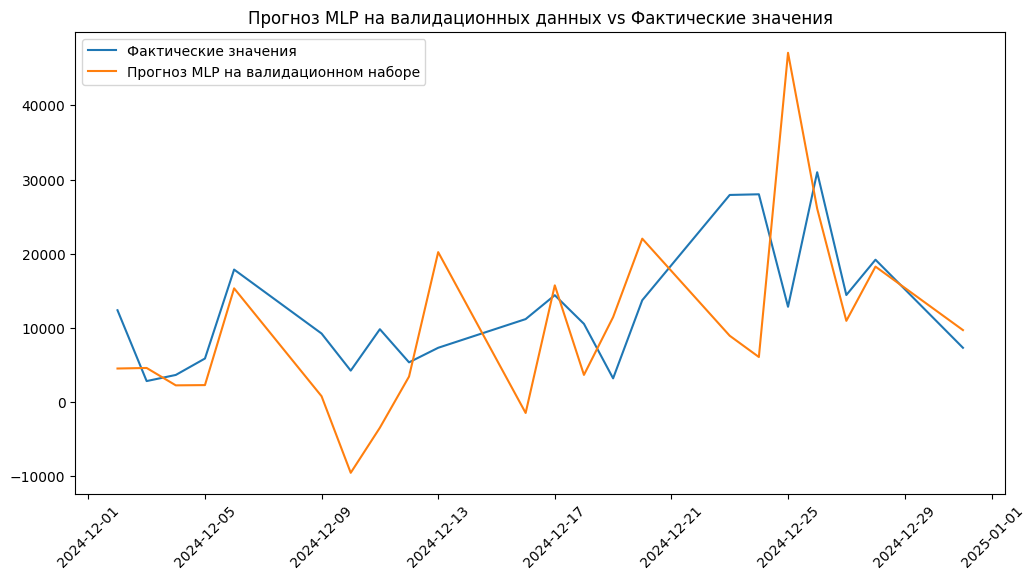

In [38]:
# смотрим на графике 
plt.figure(figsize=(12, 6))
plt.plot(y_val_original.index, y_val_original.values, label='Фактические значения')
plt.plot(y_val_original.index, y_val_pred_mlp, label='Прогноз MLP на валидационном наборе')
plt.xticks(rotation=45)
plt.title('Прогноз MLP на валидационных данных vs Фактические значения')
plt.legend()
plt.show()


In [39]:
y_val_original.describe()

count      22.00
mean    12390.81
std      8166.39
min      2843.33
25%      6245.21
50%     10876.77
75%     14436.03
max     30993.42
dtype: float64

<a id='Catboost-подготовка-данных'></a> 
## Catboost

### Подготовка данных  
[К содержанию](#К-содержанию)


<a id='Catboost-построение-и-обучение-модели'></a> 
### Построение и обучение модели
[К содержанию](#К-содержанию)

In [40]:
# подготовим обучение
cat_features = ['day_of_week', 'week_number']

# итоговый пайплайн
pipe_final = Pipeline([
    ('model', CatBoostRegressor(
        silent=True,
        random_state=RANDOM_STATE,
        cat_features=cat_features))
])

# сетка гиперпараметров
param_grid = [
    # CatBoostRegressor
    {
        'model__iterations': [100,200,500],
        'model__depth': [2,5,7],
        'model__learning_rate': [0.1,0.001],
        'model__l2_leaf_reg': [2],
        #'model__subsample': [0.8],
        'model__loss_function': ['RMSE'], # 'MAE', 'Quantile:alpha=0.8'],
        'model__max_bin': [256],
        'model__random_strength': [1],
        'model__early_stopping_rounds':[10]
        
    }
]

In [41]:
# полный перебор гиперпараметров с помощью GridSearchCV
grid_search = GridSearchCV(
    pipe_final,
    param_grid=param_grid,
    cv=n_splits,
    scoring={'neg_mean_squared_error': 'neg_mean_squared_error','smape': smape_scorer},
    refit='neg_mean_squared_error',
    n_jobs=-1,
    error_score='raise'
)

# обучение модели
model = grid_search.fit(X_train, y_train)

# выгружаем метрики
best_score_neg_mse = grid_search.best_score_
best_score_rmse = round(np.sqrt(-best_score_neg_mse), 3)
best_score_smape = round(-grid_search.cv_results_['mean_test_smape'][grid_search.best_index_], 3)

# выводим результаты
print(f'Метрика RMSE лучшей модели на тренировочной выборке при кросс-валидации: {best_score_rmse}')
print(f'Метрика SMAPE лучшей модели на тренировочной выборке при кросс-валидации: {best_score_smape}')
print(f'Параметры лучшей модели: {grid_search.best_params_}')

Метрика RMSE лучшей модели на тренировочной выборке при кросс-валидации: 9405.909
Метрика SMAPE лучшей модели на тренировочной выборке при кросс-валидации: 75.919
Параметры лучшей модели: {'model__depth': 2, 'model__early_stopping_rounds': 10, 'model__iterations': 500, 'model__l2_leaf_reg': 2, 'model__learning_rate': 0.001, 'model__loss_function': 'RMSE', 'model__max_bin': 256, 'model__random_strength': 1}


In [42]:
# берем модель CatBoostRegressor из пайплайна
catboost_model = model.best_estimator_.named_steps["model"]

# получаем важность признаков
feature_importances = catboost_model.get_feature_importance()
feature_names = catboost_model.feature_names_

# преобразовываем в DataFrame, сортируем и выводим
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

                                  Feature  Importance
34                   project_id_ufreq_std       14.50
32                contractor_id_ufreq_std       13.80
38          articles__parent_id_ufreq_std       13.53
21               contractor_id_ufreq_mean       12.26
27         articles__parent_id_ufreq_mean        8.23
23                  project_id_ufreq_mean        6.76
41                   robots__id_ufreq_std        5.65
33                   article_id_ufreq_std        5.19
16                      day_purpose_pca_2        5.02
30                  robots__id_ufreq_mean        3.69
22                  article_id_ufreq_mean        2.46
11                     day_payments_count        1.32
37                 donor_cat_id_ufreq_std        1.30
26                donor_cat_id_ufreq_mean        0.86
14                       day_purpose_mean        0.61
1               day_contractor_id_nunique        0.60
13                        day_max_payment        0.58
49                 day_payme

<a id='Catboost-валидация-модели-с-визуализацией-прогноза'></a> 
### Валидация модели с визуализацией прогноза
[К содержанию](#К-содержанию)

Метрика RMSE  на валидационном наборе: 8239.24
Метрика SMAPE на валидационном наборе: 51.59


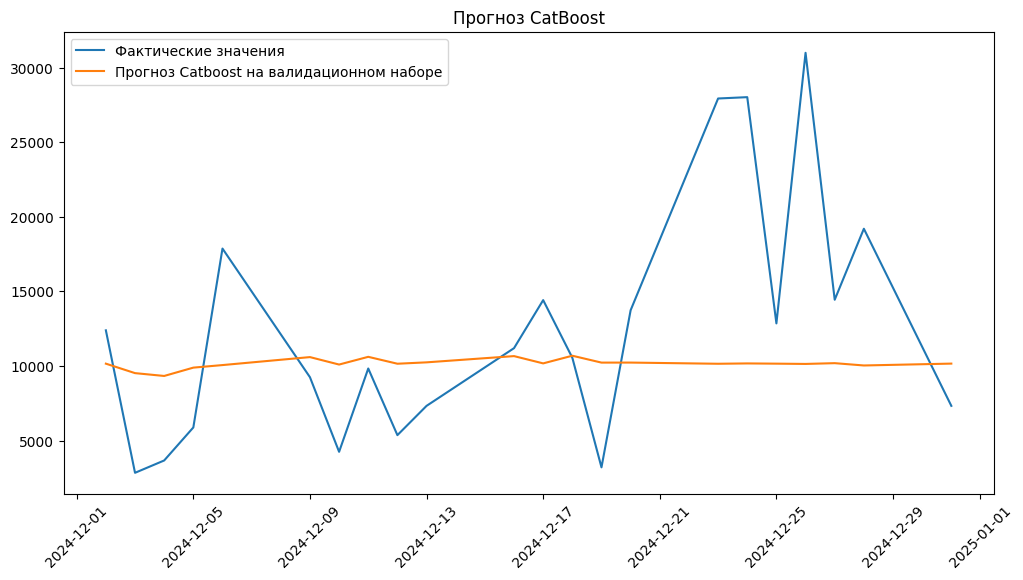

In [43]:
# тестирование catboost на валидационной выборке

# переобучаем лучшую модель на всем тренировочном наборе
final_model_cb = grid_search.best_estimator_
final_model_cb.fit(X_train, y_train)

# делаем прогноз и считаем метрики RMSE и SMAPE на валидационном наборе
y_val_pred_cb = np.round(final_model_cb.predict(X_val), decimals=2)

rmse_val_cb = np.sqrt(mean_squared_error(y_val, y_val_pred_cb))
smape_metrics_val_cb = smape(y_val, y_val_pred_cb)

# выводим метрики
print(f'Метрика RMSE  на валидационном наборе: {rmse_val_cb:.2f}')
print(f'Метрика SMAPE на валидационном наборе: {smape_metrics_val_cb:.2f}')

# смотрим на графике 
plt.figure(figsize=(12, 6))
plt.plot(y_val.index, y_val.values, label='Фактические значения')
plt.plot(y_val.index, y_val_pred_cb, label='Прогноз Catboost на валидационном наборе')
plt.xticks(rotation=45)
plt.title('Прогноз CatBoost')
plt.legend()
plt.show()


In [44]:
y_val.describe()

count      22.00
mean    12390.81
std      8166.39
min      2843.33
25%      6245.21
50%     10876.77
75%     14436.03
max     30993.42
Name: target_shifted, dtype: float64

<a id='Подбор-модели-ансамбля-прогнозов-на-валидационной-выборке'></a> 
## Подбор модели ансамбля прогнозов на валидационной выборке
[К содержанию](#К-содержанию)

Сверим размерности и временые ряды истинных валидационных значений и предсказаний разных моделей:

In [45]:
#MLP
display(y_val_original.shape)
display(y_val_original.head(3),
        y_val_original.tail(3))

display(y_val_pred_mlp.shape)
display(y_val_pred_mlp[:3],
        y_val_pred_mlp[-3:])

(22,)

2024-12-02   12392.94
2024-12-03    2843.33
2024-12-04    3669.98
dtype: float32

2024-12-27   14442.02
2024-12-28   19201.81
2024-12-31    7330.78
dtype: float32

(22,)

array([4536.79, 4610.04, 2267.26], dtype=float32)

array([10962.24, 18272.95,  9715.02], dtype=float32)

In [46]:
#Catboost
display(y_val.shape)
display(y_val.head(3),
        y_val.tail(3))

display(y_val_pred_cb.shape)
display(y_val_pred_cb[:3],
        y_val_pred_cb[-3:])


(22,)

2024-12-02   12392.94
2024-12-03    2843.33
2024-12-04    3669.98
Name: target_shifted, dtype: float64

2024-12-27   14442.02
2024-12-28   19201.81
2024-12-31    7330.78
Name: target_shifted, dtype: float64

(22,)

array([10159.13,  9524.48,  9334.67])

array([10192.39, 10037.52, 10162.77])

In [47]:
forecasts_val = y_val.to_frame(name='y_actual') 
forecasts_val['forecast_mlp'] = pd.Series(y_val_pred_mlp, index=y_val.index)
forecasts_val['forecast_catboost'] = pd.Series(y_val_pred_cb, index=y_val.index)

display(forecasts_val.isna().sum().sum())
display(forecasts_val.head(2),
        forecasts_val.tail(2))


0

,y_actual,forecast_mlp,forecast_catboost
2024-12-02,12392.94,4536.79,10159.13
2024-12-03,2843.33,4610.04,9524.48


,y_actual,forecast_mlp,forecast_catboost
2024-12-28,19201.81,18272.95,10037.52
2024-12-31,7330.78,9715.02,10162.77


In [48]:
# сверим метрики
forecast_columns = forecasts_val.columns[1:]
for column in forecast_columns:
    print(f"Модель: {column}")
    print(f"Метрика RMSE на валидационном наборе: {np.sqrt(mean_squared_error(forecasts_val['y_actual'], forecasts_val[column])):.2f}")
    print(f"Метрика SMAPE на валидационном наборе: {smape(forecasts_val['y_actual'], forecasts_val[column]):.2f}\n")


Модель: forecast_mlp
Метрика RMSE на валидационном наборе: 11861.73
Метрика SMAPE на валидационном наборе: 85.59

Модель: forecast_catboost
Метрика RMSE на валидационном наборе: 8239.24
Метрика SMAPE на валидационном наборе: 51.59



Взвесим прогнозы тремя способами - через среднее, линейную регрессию и нейросеть:

In [49]:
# считаем средние прогнозы
forecasts_val['forecast_mean'] = forecasts_val[forecast_columns].mean(axis=1)

forecasts_val.head()

,y_actual,forecast_mlp,forecast_catboost,forecast_mean
2024-12-02,12392.94,4536.79,10159.13,7347.96
2024-12-03,2843.33,4610.04,9524.48,7067.26
2024-12-04,3669.98,2267.26,9334.67,5800.97
2024-12-05,5883.35,2301.51,9892.92,6097.22
2024-12-06,17873.12,15343.77,10064.09,12703.93


In [50]:
print(f"Метрика RMSE на валидационном наборе по средним прогнозам 2-х моделей: {np.sqrt(mean_squared_error(forecasts_val['y_actual'], forecasts_val['forecast_mean'])):.2f}")
print(f"Метрика SMAPE на валидационном наборе по средним прогнозам 2-х моделей: {smape(forecasts_val['y_actual'], forecasts_val['forecast_mean']):.2f}\n")

Метрика RMSE на валидационном наборе по средним прогнозам 2-х моделей: 8319.15
Метрика SMAPE на валидационном наборе по средним прогнозам 2-х моделей: 59.65



In [51]:
# обучим линейную регрессию (ridge) для взвешивания прогнозов трех моделей

# выбираем прогнозы моделей как фичи
X_meta = forecasts_val[['forecast_mlp', 'forecast_catboost']]
y_meta = forecasts_val['y_actual']

# обучаем Ridge-регрессию с коэффициентом регуляризации
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_meta, y_meta)

# делаем предсказание на валидационной же выборке
forecasts_val['forecast_ridge'] = ridge_model.predict(X_meta)

# выводим коэффициенты
print("Коэффициенты Ridge:", ridge_model.coef_)
print("Свободный член (intercept):", ridge_model.intercept_)

Коэффициенты Ridge: [0.25505525 4.89666216]
Свободный член (intercept): -39941.80650333743


In [52]:
print(f"Метрика RMSE на валидационном наборе по прогнозам 2-х моделей (веса по линейной регрессии): {np.sqrt(mean_squared_error(forecasts_val['y_actual'], forecasts_val['forecast_ridge'])):.2f}")
print(f"Метрика SMAPE на валидационном наборе по прогнозам 2-х моделей (веса по линейной регрессии): {smape(forecasts_val['y_actual'], forecasts_val['forecast_ridge']):.2f}\n")

Метрика RMSE на валидационном наборе по прогнозам 2-х моделей (веса по линейной регрессии): 7276.10
Метрика SMAPE на валидационном наборе по прогнозам 2-х моделей (веса по линейной регрессии): 45.41



In [53]:
# обучим простую нейросеть для взвешивания прогнозов двух моделей

# преобразуем прогнозы на валидацинной выборке в тензоры PyTorch
X_meta_tensor = torch.tensor(X_meta.values, dtype=torch.float32)
y_meta_tensor = torch.tensor(y_meta.values, dtype=torch.float32)

# задаем модель нейросети
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc = nn.Linear(2, 1)  # 3 входных признака-прогноза

    def forward(self, x):
        return self.fc(x)

# инициализируем модель
model_meta = SimpleNN()

# определяем функцию потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.Adam(model_meta.parameters(), lr=0.001)

# обучаем модель
num_epochs = 500
for epoch in range(num_epochs):
    # прямой проход
    outputs = model_meta(X_meta_tensor).squeeze()
    loss = criterion(outputs, y_meta_tensor)

    # обратный проход и оптимизация
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:  # печатаем каждый 50-й шаг
        print(f"Эпоха [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# прогнозируем на валидационных данных
forecasts_val['forecast_nn'] = model_meta(X_meta_tensor).detach().numpy()

# выводим коэффициенты и смещение
print("Коэффициенты (веса):", model_meta.fc.weight)
print("Смещение (bias):", model_meta.fc.bias)

Эпоха [50/500], Loss: 177734192.0000
Эпоха [100/500], Loss: 165543936.0000
Эпоха [150/500], Loss: 156049824.0000
Эпоха [200/500], Loss: 148414096.0000
Эпоха [250/500], Loss: 141930048.0000
Эпоха [300/500], Loss: 136103152.0000
Эпоха [350/500], Loss: 130655032.0000
Эпоха [400/500], Loss: 125463760.0000
Эпоха [450/500], Loss: 120491264.0000
Эпоха [500/500], Loss: 115733040.0000
Коэффициенты (веса): Parameter containing:
tensor([[ 0.6961, -0.0196]], requires_grad=True)
Смещение (bias): Parameter containing:
tensor([0.3562], requires_grad=True)


In [54]:
print(f"Метрика RMSE на валидационном наборе по прогнозам 2-х моделей(веса по нейросети): {np.sqrt(mean_squared_error(forecasts_val['y_actual'], forecasts_val['forecast_nn'])):.2f}")
print(f"Метрика SMAPE на валидационном наборе по прогнозам 2-х моделей(веса по нейросети): {smape(forecasts_val['y_actual'], forecasts_val['forecast_nn']):.2f}\n")

Метрика RMSE на валидационном наборе по прогнозам 2-х моделей(веса по нейросети): 10753.61
Метрика SMAPE на валидационном наборе по прогнозам 2-х моделей(веса по нейросети): 95.88



<a id='Тестирование-ансамбля-прогнозов-на-тестовой-выборке'></a> 
## Тестирование ансамбля прогнозов на тестовой выборке
[К содержанию](#К-содержанию)

In [55]:
# делаем тестовые прогнозы от модели MLP

# преобразуем в тензоры
X_test_tensor = torch.tensor(X_test_prepared.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled.values, dtype=torch.float32).view(-1, 1)

# делаем прогноз
model_mlp.eval()
with torch.no_grad():
    y_pred = model_mlp(X_test_tensor)

# разворачиваем масштабированные данные
y_test_original = np.round(scaler_y.inverse_transform(y_test_tensor.numpy()).flatten(), decimals=2)
y_test_pred_mlp = np.round(scaler_y.inverse_transform(y_pred.numpy()).flatten(), decimals=2)

# преобразуем y_test_original в Series с правильными временными индексами
y_test_original = pd.Series(y_test_original, index=y_test_scaled.index)

# считаем метрики
rmse_test_mlp = np.sqrt(mean_squared_error(y_test_original, y_test_pred_mlp))
smape_test_mlp = smape(y_test_original, y_test_pred_mlp)

print(f'Метрика RMSE на финальных тестовых данных: {rmse_test_mlp:.3f}')
print(f'Метрика SMAPE на финальных тестовых данных: {smape_test_mlp:.4f}')



Метрика RMSE на финальных тестовых данных: 31576.746
Метрика SMAPE на финальных тестовых данных: 135.2922


In [56]:
# делаем тестовые прогнозы от модели Catboost

# делаем прогноз и считаем метрики RMSE и SMAPE на тестовом наборе
y_test_pred_cb = np.round(final_model_cb.predict(X_test), decimals=2)

rmse_test_cb = np.sqrt(mean_squared_error(y_test, y_test_pred_cb))
smape_metrics_test_cb = smape(y_test, y_test_pred_cb)

print(f'Метрика RMSE  на тестовом наборе: {rmse_test_cb:.2f}')
print(f'Метрика SMAPE на тестовом наборе: {smape_metrics_test_cb:.2f}')


Метрика RMSE  на тестовом наборе: 6201.01
Метрика SMAPE на тестовом наборе: 76.63


In [57]:
# собираем тестовые прогнозы в датафрейм
forecasts_test = y_test.to_frame(name='y_actual') 
forecasts_test['forecast_mlp'] = pd.Series(y_test_pred_mlp, index=y_test.index)
forecasts_test['forecast_catboost'] = pd.Series(y_test_pred_cb, index=y_test.index)

display(forecasts_test.isna().sum().sum())
display(forecasts_test.head(2),
        forecasts_test.tail(2))


0

,y_actual,forecast_mlp,forecast_catboost
2025-01-09,4650.22,-21741.16,10713.61
2025-01-10,16207.28,16693.77,10206.57


,y_actual,forecast_mlp,forecast_catboost
2025-01-23,2739.27,40157.26,10661.09
2025-01-24,6224.93,41087.14,9567.91


In [58]:
# предсказание ансамблем со взвешиванием линейной регрессией

# выбираем прогнозы моделей как фичи
X_meta_test = forecasts_test[['forecast_mlp', 'forecast_catboost']]
y_meta_test = forecasts_test['y_actual']

forecasts_test['forecast_ridge'] = ridge_model.predict(X_meta_test)

ens_linear_rmse = np.sqrt(mean_squared_error(forecasts_test['y_actual'], forecasts_test['forecast_ridge']))
ens_linear_smape = smape(forecasts_test['y_actual'], forecasts_test['forecast_ridge'])

print(f"Метрика RMSE на тестовом наборе по прогнозам 2-х моделей (веса по линейной регрессии): {ens_linear_rmse:.2f}")
print(f"Метрика SMAPE на тестовом наборе по прогнозам 2-х моделей (веса по линейной регрессии): {ens_linear_smape:.2f}\n")

Метрика RMSE на тестовом наборе по прогнозам 2-х моделей (веса по линейной регрессии): 13844.49
Метрика SMAPE на тестовом наборе по прогнозам 2-х моделей (веса по линейной регрессии): 95.81



In [59]:
# предсказание ансамблем с взвешиванием нейросетью

# преобразуем данные в тензоры PyTorch
X_meta_test_tensor = torch.tensor(X_meta_test.values, dtype=torch.float32)
y_meta_test_tensor = torch.tensor(y_meta_test.values, dtype=torch.float32)

# прогнозируем на тестовых данных
forecasts_test['forecast_nn'] = model_meta(X_meta_test_tensor).detach().numpy()

ens_nn_rmse = np.sqrt(mean_squared_error(forecasts_test['y_actual'], forecasts_test['forecast_nn']))
ens_nn_smape = smape(forecasts_test['y_actual'], forecasts_test['forecast_nn'])

print(f"Метрика RMSE на тестовом наборе по прогнозам 2-х моделей(веса по нейросети): {ens_nn_rmse:.2f}")
print(f"Метрика SMAPE на тестовом наборе по прогнозам 2-х моделей(веса по нейросети): {ens_nn_smape:.2f}\n")

Метрика RMSE на тестовом наборе по прогнозам 2-х моделей(веса по нейросети): 20742.57
Метрика SMAPE на тестовом наборе по прогнозам 2-х моделей(веса по нейросети): 124.87



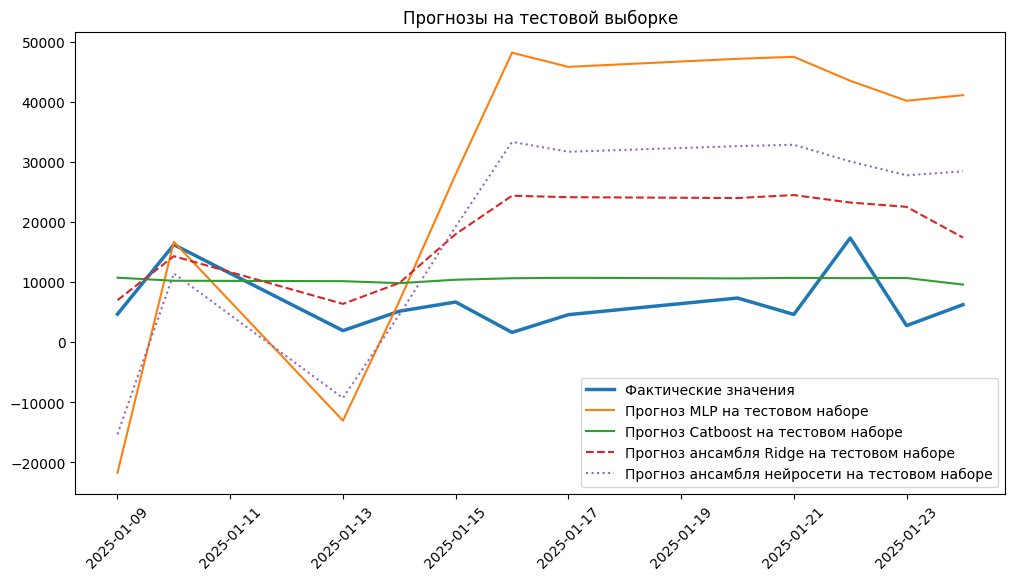

In [60]:
# посмотрим тестовые прогнозы на графике 
plt.figure(figsize=(12, 6))

plt.plot(y_test.index, y_test.values, label='Фактические значения', linewidth=2.5)
plt.plot(y_test.index, y_test_pred_mlp, label='Прогноз MLP на тестовом наборе')
plt.plot(y_test.index, y_test_pred_cb, label='Прогноз Catboost на тестовом наборе')
plt.plot(y_test.index, forecasts_test['forecast_ridge'], label='Прогноз ансамбля Ridge на тестовом наборе', linestyle='--')
plt.plot(y_test.index, forecasts_test['forecast_nn'], label='Прогноз ансамбля нейросети на тестовом наборе', linestyle=':')

plt.xticks(rotation=45)
plt.title('Прогнозы на тестовой выборке')
plt.legend()
plt.show()


In [61]:
y_test.describe()

count      12.00
mean     6578.78
std      5081.37
min      1603.68
25%      4105.62
50%      4894.31
75%      6830.76
max     17324.52
Name: target_shifted, dtype: float64

In [62]:
if os.path.exists("comparison.csv"):
    comparison = pd.read_csv("comparison.csv")
else:
    comparison = pd.DataFrame(columns=['fund_id'])

# проверяем, есть ли уже этот фонд
if FUND_ID in comparison['fund_id'].values:
    # обновляем существующую строку
    comparison.loc[comparison['fund_id'] == FUND_ID, '2models_mlp_rmse'] = rmse_test_mlp
    comparison.loc[comparison['fund_id'] == FUND_ID, '2models_mlp_smape'] = smape_test_mlp
    comparison.loc[comparison['fund_id'] == FUND_ID, '2models_catboost_rmse'] = rmse_test_cb
    comparison.loc[comparison['fund_id'] == FUND_ID, '2models_catboost_smape'] = smape_metrics_test_cb
    comparison.loc[comparison['fund_id'] == FUND_ID, '2models_ens_linear_rmse'] = ens_linear_rmse
    comparison.loc[comparison['fund_id'] == FUND_ID, '2models_ens_linear_smape'] = ens_linear_smape
    comparison.loc[comparison['fund_id'] == FUND_ID, '2models_ens_nn_rmse'] = ens_nn_rmse
    comparison.loc[comparison['fund_id'] == FUND_ID, '2models_ens_nn_smape'] = ens_nn_smape
else:
    # создаем новую строку
    new_row = pd.DataFrame({
        'fund_id': [FUND_ID],
        '2models_mlp_rmse': [rmse_test_mlp],
        '2models_mlp_smape': [smape_test_mlp],
        '2models_catboost_rmse': [rmse_test_cb],
        '2models_catboost_smape': [smape_metrics_test_cb],
        '2models_ens_linear_rmse': [ens_linear_rmse],
        '2models_ens_linear_smape': [ens_linear_smape],
        '2models_ens_nn_rmse': [ens_nn_rmse],
        '2models_ens_nn_smape': [ens_nn_smape]
    })

    comparison = pd.concat([comparison, new_row], ignore_index=True)

# сохраняем обратно
comparison.to_csv("comparison.csv", index=False)